Best K value: 1
Maximum Accuracy: 1.0

Final Accuracy: 1.0


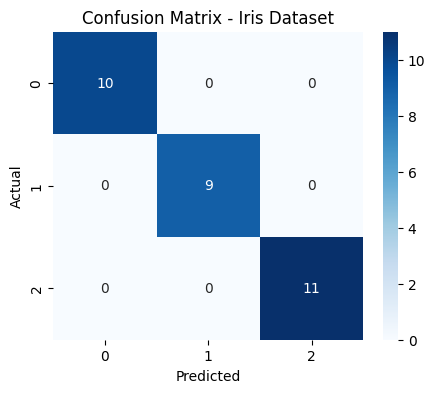


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [3]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load built-in Iris dataset
iris = load_iris()

# Features and Target
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling (optional but recommended)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Find best K value
accuracy_list = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, y_pred))

# Best K
best_k = accuracy_list.index(max(accuracy_list)) + 1
print("Best K value:", best_k)
print("Maximum Accuracy:", max(accuracy_list))

# Train final model with best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Final Accuracy
print("\nFinal Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Iris Dataset")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Please upload your 'diabetes.csv' file


Saving diabetes.csv to diabetes.csv
Dataset loaded successfully! First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Best K for Diabetes: 18
Accuracy on test data: 0.7597


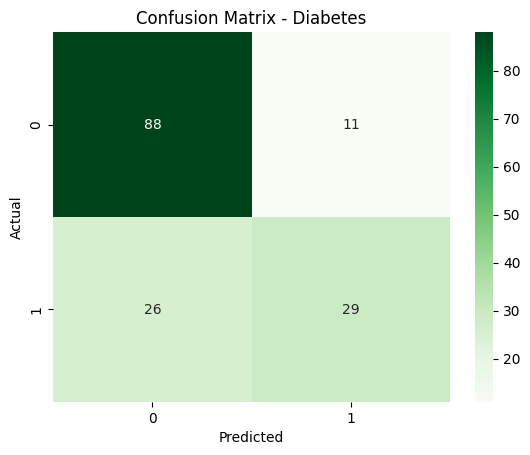


Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.89      0.83        99
           1       0.72      0.53      0.61        55

    accuracy                           0.76       154
   macro avg       0.75      0.71      0.72       154
weighted avg       0.76      0.76      0.75       154



In [12]:
# ================= DIABETES DATASET WITH FILE UPLOAD =================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# For Google Colab upload
try:
    from google.colab import files
    upload_mode = True
except ImportError:
    upload_mode = False

# Upload CSV file if needed
if upload_mode:
    print("Please upload your 'diabetes.csv' file")
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
else:
    file_name = "diabetes.csv"  # default local file

# Load diabetes dataset
diabetes = pd.read_csv(file_name)
print("Dataset loaded successfully! First 5 rows:")
print(diabetes.head())

# Features and target
X = diabetes.drop("Outcome", axis=1)
y = diabetes["Outcome"]

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Find best K
accuracy_list = []
for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred_temp = model.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, y_pred_temp))

best_k = accuracy_list.index(max(accuracy_list)) + 1
print(f"Best K for Diabetes: {best_k}")

# Train final model
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Accuracy
print(f"Accuracy on test data: {accuracy_score(y_test, y_pred):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
plt.title("Confusion Matrix - Diabetes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Please upload your 'heart.csv' file


Saving heart.csv to heart.csv
Heart dataset loaded successfully! First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
Best K for Heart dataset: 7
Accuracy on test data: 0.9180


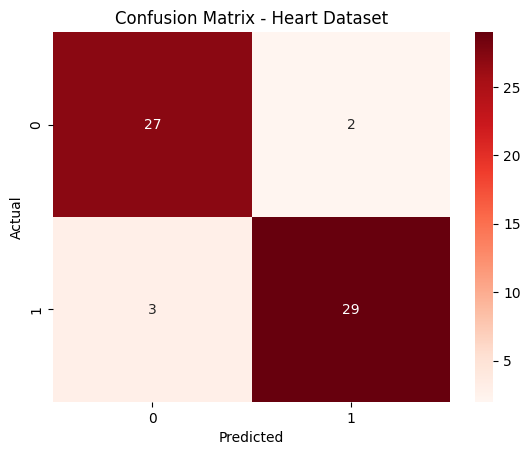


Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [13]:
# ================= HEART DATASET KNN =================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# For Google Colab upload
try:
    from google.colab import files
    upload_mode = True
except ImportError:
    upload_mode = False

# Upload CSV file if needed
file_name = "heart.csv"
if upload_mode:
    print("Please upload your 'heart.csv' file")
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]

# Load dataset
heart = pd.read_csv(file_name)
print("Heart dataset loaded successfully! First 5 rows:")
print(heart.head())

# ================= FEATURES AND TARGET =================
# Assuming 'target' is the column to predict
X = heart.drop("target", axis=1)
y = heart["target"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (important for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================= FIND BEST K =================
accuracy_list = []
for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred_temp = model.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, y_pred_temp))

best_k = accuracy_list.index(max(accuracy_list)) + 1
print(f"Best K for Heart dataset: {best_k}")

# ================= TRAIN FINAL MODEL =================
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# ================= RESULTS =================
# Accuracy
print(f"Accuracy on test data: {accuracy_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Reds")
plt.title("Confusion Matrix - Heart Dataset")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))